In [1]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)
print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
def generate_telco_churn_data(n=7000, seed=42):
    rng = np.random.default_rng(seed)

    gender = rng.choice(["Male", "Female"], n)
    senior_citizen = rng.choice([0, 1], n, p=[0.84, 0.16])
    partner = rng.choice(["Yes", "No"], n, p=[0.48, 0.52])
    dependents = rng.choice(["Yes", "No"], n, p=[0.30, 0.70])

    tenure = rng.integers(0, 73, n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.24, 0.21])
    phone_service = rng.choice(["Yes", "No"], n, p=[0.90, 0.10])
    internet_service = rng.choice(["DSL", "Fiber optic", "No"], n, p=[0.34, 0.44, 0.22])

    online_security = np.where(internet_service == "No", "No internet service",
                                rng.choice(["Yes", "No"], n))
    tech_support = np.where(internet_service == "No", "No internet service",
                             rng.choice(["Yes", "No"], n))
    streaming_tv = np.where(internet_service == "No", "No internet service",
                             rng.choice(["Yes", "No"], n))
    paperless_billing = rng.choice(["Yes", "No"], n, p=[0.59, 0.41])
    payment_method = rng.choice(
        ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"],
        n)

    base_charge = np.where(internet_service == "Fiber optic", 70,
                   np.where(internet_service == "DSL", 45, 20))
    monthly_charges = np.round(base_charge + rng.normal(10, 12, n).clip(-15, 40), 2)
    monthly_charges = monthly_charges.clip(18, 120)
    total_charges = np.round(monthly_charges * tenure + rng.normal(0, 20, n), 2).clip(0)

    # Churn probability driven by realistic risk factors
    churn_score = (
        (contract == "Month-to-month") * 0.35
        + (internet_service == "Fiber optic") * 0.15
        + (tech_support == "No") * 0.15
        + (online_security == "No") * 0.10
        + (paperless_billing == "Yes") * 0.08
        + (payment_method == "Electronic check") * 0.10
        + (tenure < 12) * 0.20
        - (tenure > 48) * 0.20
        - (contract == "Two year") * 0.20
        + rng.normal(0, 0.12, n)
    )
    churn_prob = 1 / (1 + np.exp(-4 * (churn_score - 0.35)))
    churn = np.where(rng.random(n) < churn_prob, "Yes", "No")

    df = pd.DataFrame({
        "customerID": [f"CUST-{i:05d}" for i in range(n)],
        "gender": gender,
        "SeniorCitizen": senior_citizen,
        "Partner": partner,
        "Dependents": dependents,
        "tenure": tenure,
        "PhoneService": phone_service,
        "InternetService": internet_service,
        "OnlineSecurity": online_security,
        "TechSupport": tech_support,
        "StreamingTV": streaming_tv,
        "Contract": contract,
        "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges,
        "Churn": churn,
    })
    return df

df = generate_telco_churn_data()
df.to_csv("telco_churn_data.csv", index=False)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (7000, 17)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-00000,Male,0,Yes,No,20,Yes,DSL,No,No,No,One year,No,Electronic check,65.96,1303.71,No
1,CUST-00001,Female,0,Yes,No,49,Yes,Fiber optic,Yes,Yes,Yes,Two year,No,Electronic check,55.00,2684.86,No
2,CUST-00002,Female,0,Yes,Yes,69,Yes,DSL,Yes,No,Yes,One year,Yes,Credit card (automatic),50.54,3482.39,Yes
3,CUST-00003,Male,0,No,No,37,Yes,Fiber optic,Yes,No,No,Month-to-month,Yes,Credit card (automatic),75.09,2799.84,Yes
4,CUST-00004,Male,0,No,No,40,Yes,Fiber optic,No,Yes,Yes,Two year,No,Credit card (automatic),74.43,2969.31,No


## 4. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7000 non-null   str    
 1   gender            7000 non-null   str    
 2   SeniorCitizen     7000 non-null   int64  
 3   Partner           7000 non-null   str    
 4   Dependents        7000 non-null   str    
 5   tenure            7000 non-null   int64  
 6   PhoneService      7000 non-null   str    
 7   InternetService   7000 non-null   str    
 8   OnlineSecurity    7000 non-null   str    
 9   TechSupport       7000 non-null   str    
 10  StreamingTV       7000 non-null   str    
 11  Contract          7000 non-null   str    
 12  PaperlessBilling  7000 non-null   str    
 13  PaymentMethod     7000 non-null   str    
 14  MonthlyCharges    7000 non-null   float64
 15  TotalCharges      7000 non-null   float64
 16  Churn             7000 non-null   str    
dtypes: flo

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7000,7000,CUST-00000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7000,2,Male,3554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7000.0,NaN,NaN,NaN,0.153714,0.3607,0.0,0.0,0.0,0.0,1.0
Partner,7000,2,No,3685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7000,2,No,4940,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7000.0,NaN,NaN,NaN,36.123714,20.880014,0.0,18.0,36.0,54.0,72.0
PhoneService,7000,2,Yes,6273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7000,3,Fiber optic,3114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7000,3,No,2801,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TechSupport,7000,3,No,2775,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nOverall churn rate: {:.2f}%".format((df["Churn"] == "Yes").mean() * 100))


Missing values per column:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
InternetService     0
OnlineSecurity      0
TechSupport         0
StreamingTV         0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Overall churn rate: 51.00%


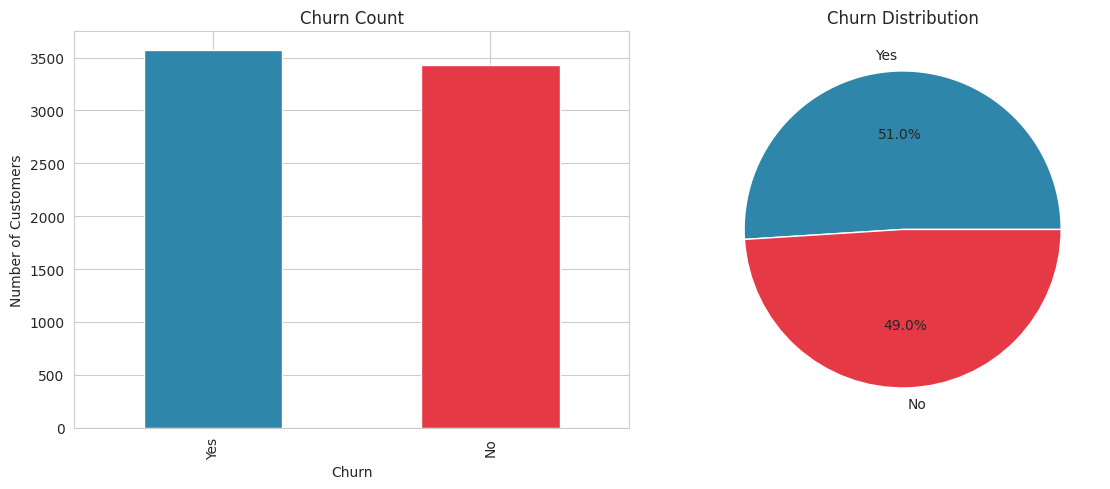

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df["Churn"].value_counts().plot(kind="bar", ax=ax[0], color=["#2E86AB", "#E63946"])
ax[0].set_title("Churn Count")
ax[0].set_xlabel("Churn")
ax[0].set_ylabel("Number of Customers")

df["Churn"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[1],
                                 colors=["#2E86AB", "#E63946"])
ax[1].set_title("Churn Distribution")
ax[1].set_ylabel("")
plt.tight_layout()
plt.savefig("churn_distribution.png", dpi=120)
plt.show()


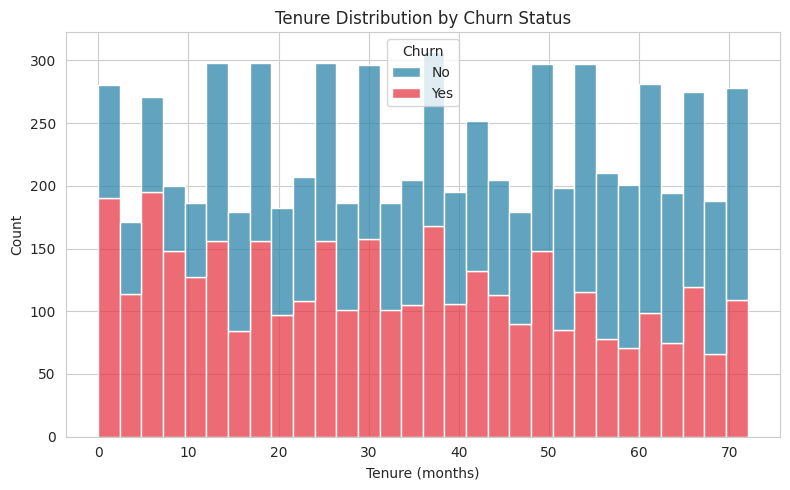

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, palette=["#2E86AB", "#E63946"])
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (months)")
plt.tight_layout()
plt.savefig("tenure_vs_churn.png", dpi=120)
plt.show()


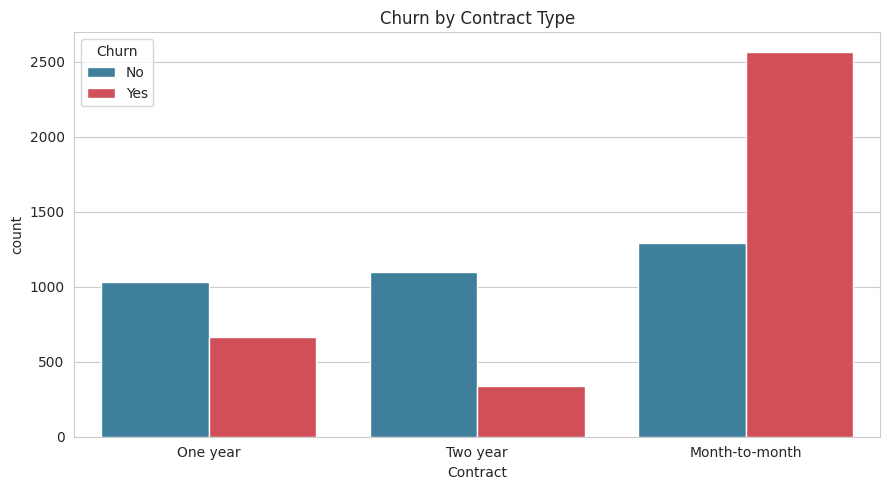

In [8]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Contract", hue="Churn", palette=["#2E86AB", "#E63946"])
plt.title("Churn by Contract Type")
plt.tight_layout()
plt.savefig("contract_vs_churn.png", dpi=120)
plt.show()


/tmp/ipykernel_139/1707259277.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#2E86AB", "#E63946"])


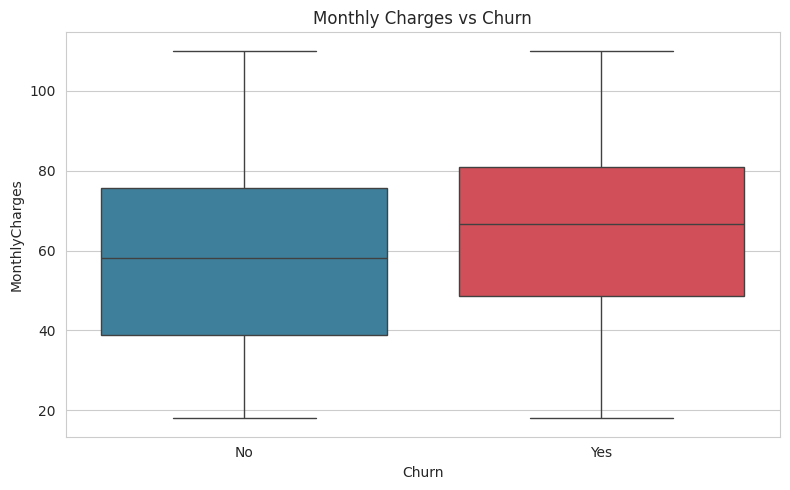

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#2E86AB", "#E63946"])
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
plt.savefig("charges_vs_churn.png", dpi=120)
plt.show()


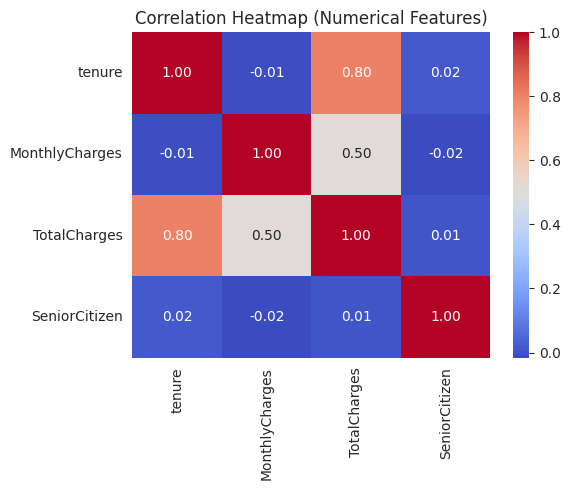

In [10]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()


## 5. Data Preprocessing

In [11]:
model_df = df.drop(columns=["customerID"]).copy()

# Encode target
model_df["Churn"] = model_df["Churn"].map({"Yes": 1, "No": 0})

# Encode categorical features
cat_cols = model_df.select_dtypes(include="object").columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (5600, 15)  Test shape: (1400, 15)


/tmp/ipykernel_139/2223288493.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df.select_dtypes(include="object").columns.tolist()


## 6. Model Building — AI-Powered Churn Prediction
Two models are trained and compared: Logistic Regression (baseline) and Random Forest (ensemble).

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1 Score :", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_proba), 3))
    print()

evaluate("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)


--- Logistic Regression ---
Accuracy : 0.683
Precision: 0.684
Recall   : 0.702
F1 Score : 0.693
ROC-AUC  : 0.754

--- Random Forest ---
Accuracy : 0.681
Precision: 0.683
Recall   : 0.699
F1 Score : 0.691
ROC-AUC  : 0.754



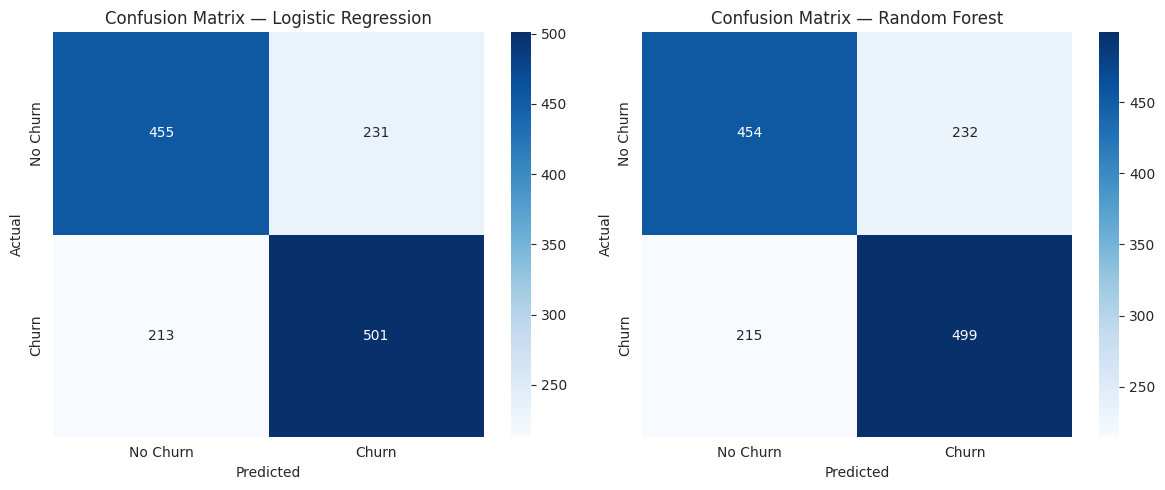

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()


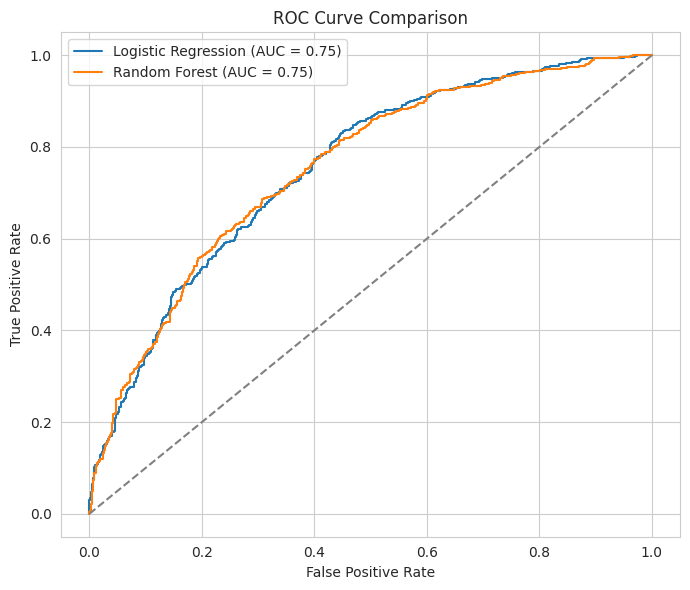

In [14]:
plt.figure(figsize=(7, 6))
for name, proba in [("Logistic Regression", y_proba_lr), ("Random Forest", y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=120)
plt.show()


## 7. Feature Importance — What Drives Churn?

/tmp/ipykernel_139/1670783166.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:10], y=importances.index[:10], palette="viridis")


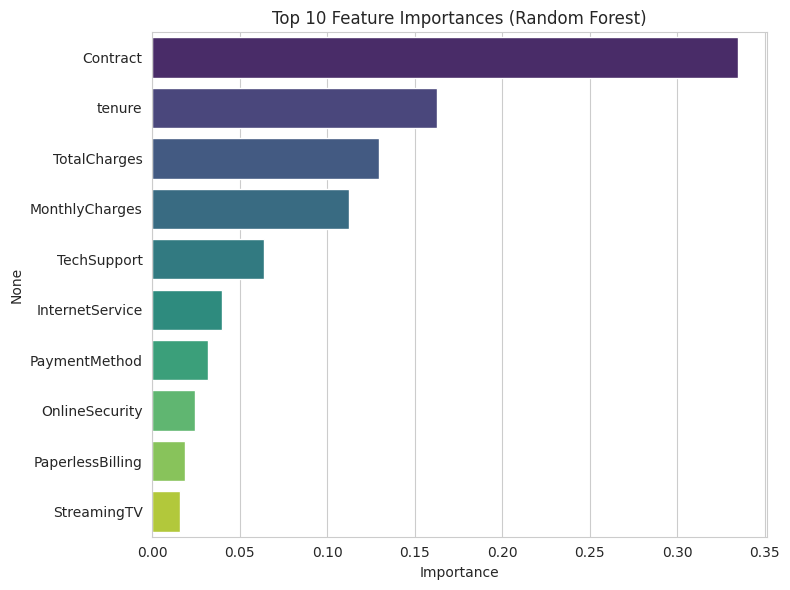

Contract            0.334764
tenure              0.162890
TotalCharges        0.129774
MonthlyCharges      0.112208
TechSupport         0.063608
InternetService     0.039679
PaymentMethod       0.031628
OnlineSecurity      0.024442
PaperlessBilling    0.018489
StreamingTV         0.015769
dtype: float64

In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], palette="viridis")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

importances.head(10)


## 8. AI-Generated Business Insights
The rule-based insight engine below translates the model's statistical findings into
plain-language, actionable business recommendations — turning raw analytics into
decision-ready intelligence.

In [16]:
def generate_ai_insights(df, importances, churn_rate):
    insights = []
    insights.append(f"Overall churn rate stands at {churn_rate:.1f}%, indicating a "
                     f"{'high' if churn_rate > 25 else 'moderate' if churn_rate > 15 else 'healthy'} "
                     f"level of customer attrition that requires attention.")

    top_feature = importances.index[0]
    insights.append(f"'{top_feature}' is the single strongest predictor of churn — "
                     f"prioritize monitoring and early-intervention on this factor.")

    mtm_churn = df[df.Contract == "Month-to-month"]["Churn"].eq("Yes").mean() * 100
    two_yr_churn = df[df.Contract == "Two year"]["Churn"].eq("Yes").mean() * 100
    insights.append(f"Month-to-month customers churn at {mtm_churn:.1f}% vs. just "
                     f"{two_yr_churn:.1f}% for two-year contracts — incentivizing longer "
                     f"contracts (discounts, loyalty perks) could materially cut churn.")

    early_churn = df[df.tenure < 12]["Churn"].eq("Yes").mean() * 100
    insights.append(f"New customers (tenure < 12 months) churn at {early_churn:.1f}%, "
                     f"suggesting an onboarding/early-engagement program would have "
                     f"outsized impact.")

    no_support_churn = df[df.TechSupport == "No"]["Churn"].eq("Yes").mean() * 100
    insights.append(f"Customers without Tech Support churn at {no_support_churn:.1f}%, "
                     f"highlighting a low-cost retention lever: proactively offering "
                     f"tech support to at-risk segments.")

    return insights

churn_rate_overall = (df["Churn"] == "Yes").mean() * 100
insights = generate_ai_insights(df, importances, churn_rate_overall)

print("AI-GENERATED BUSINESS INSIGHTS\n" + "=" * 40)
for i, ins in enumerate(insights, 1):
    print(f"{i}. {ins}\n")


AI-GENERATED BUSINESS INSIGHTS
1. Overall churn rate stands at 51.0%, indicating a high level of customer attrition that requires attention.

2. 'Contract' is the single strongest predictor of churn — prioritize monitoring and early-intervention on this factor.

3. Month-to-month customers churn at 66.5% vs. just 23.4% for two-year contracts — incentivizing longer contracts (discounts, loyalty perks) could materially cut churn.

4. New customers (tenure < 12 months) churn at 69.9%, suggesting an onboarding/early-engagement program would have outsized impact.

5. Customers without Tech Support churn at 61.2%, highlighting a low-cost retention lever: proactively offering tech support to at-risk segments.

